In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize

import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
def arrowed_spines(ax, columns, background="white"):
    """
    画左下角箭头的函数，引自dynamo
    """
    if type(columns) == str:
        columns = [columns.upper() + " 1", columns.upper() + " 2"]
    import matplotlib.pyplot as plt

    fig = plt.gcf()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    despline_all(ax)

    # removing the axis ticks
    deaxis_all(ax)

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length (x-axis)
    hw = 1.0 / 20.0 * (ymax - ymin)
    hl = 1.0 / 20.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.2  # arrow overhang

    # compute matching arrowhead length and width (y-axis)
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    fc, ec = ("w", "w") if background in ["black", "#ffffff"] else ("k", "k")
    ax.arrow(
        xmin,
        ymin,
        hl * 5 / 2,
        0,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=hw / 2,
        head_length=hl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )
    ax.arrow(
        xmin,
        ymin,
        0,
        hw * 5 / 2,
        fc=fc,
        ec=ec,
        lw=lw,
        head_width=yhw / 2,
        head_length=yhl / 2,
        overhang=ohg / 2,
        length_includes_head=True,
        clip_on=False,
    )

    ax.text(
        xmin + hl * 2.5 / 2,
        ymin - 1.5 * hw / 2,
        columns[0],
        ha="center",
        va="center",
        rotation=0,
        # size=hl * 5 / (2 * len(str(columns[0]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )
    ax.text(
        xmin - 1.5 * yhw / 2,
        ymin + hw * 2.5 / 2,
        columns[1],
        ha="center",
        va="center",
        rotation=90,
        # size=hw * 5 / (2 * len(str(columns[1]))) * 20,
        # size=matplotlib.rcParams['axes.titlesize'],
        size=np.clip((hl + yhw) * 8 / 2, 6, 18),
    )

    return ax

def despline_all(ax=None, sides=None):
    # removing the default axis on all sides:
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    if sides is None:
        sides = ["bottom", "right", "top", "left"]
    for side in sides:
        ax.spines[side].set_visible(False)


def deaxis_all(ax=None):
    # removing the axis ticks
    import matplotlib.pyplot as plt

    ax = plt.gca() if ax is None else ax

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [3]:
## 读取数据
with open('data_with_phase.pickle', 'rb') as f:
    adata = pickle.load(f)
adata.shape

(5000, 7)

In [4]:
## 归一化细胞数据
np_data = adata[:, :-1]

# for i in range(np_data.shape[1]):
#     gene_data = np_data[:, i]
#     gene_data -= gene_data.min()
#     gene_data /= gene_data.max()
#     np_data[:, i] = gene_data
np_data.shape

(5000, 6)

In [5]:
th=adata[:,-1]
minima = min(th)
maxima = max(th)
norm = matplotlib.colors.Normalize(vmin=minima, vmax=maxima)
mapper = cm.ScalarMappable(norm=norm, cmap=cm.viridis)

In [6]:
## 读取3个相位点
basin_point = loadmat('basin_point.mat')['basin_point']
basin_point.shape

(3, 6)

In [7]:
## 计算作用量的函数
def action(path: np.ndarray, vf_func: Callable[[np.ndarray], np.ndarray], D: float = 1, dt: float = 1) -> float:
    """The action function calculates the action (or functional) of a path in space, given a velocity field function
    and diffusion coefficient.

    The path is represented as an array of points in space, and the velocity field is given by vf_func. The function
    first calculates the centers of the segments between each point in the path, and then calculates the velocity at
    each of these centers by taking the average of the velocities at the two neighboring points. The difference
    between the actual velocity and the velocity field at each center is then calculated and flattened into a
    one-dimensional array. The action is then calculated by taking the dot product of this array with itself,
    multiplying by a factor of 0.5*dt/D, where dt is the time step used to define the path, and D is the diffusion
    coefficient.

    Args:
        path: An array of shape (N, d) containing the coordinates of a path with N points in d dimensions.
        vf_func: A callable that takes an array of shape (d,) as input and returns a vector field at that point.
        D: A scalar representing the diffusion coefficient.
        dt: A scalar representing the time step size.

    Returns:
        A scalar representing the action along the path.
    """
    x = (path[:-1] + path[1:]) * 0.5
    v = np.diff(path, axis=0) / dt

    s = (v - vf_func(x)).flatten()
    s = 0.5 * s.dot(s) * dt / D

    return s


def action_aux(
    path_flatten: np.ndarray,
    vf_func: Callable,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
    **kwargs,
) -> float:
    """Auxiliary function for computing the action of a path.

    Args:
        path_flatten: A 1D array representing the flattened path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.
        **kwargs: Additional keyword arguments to pass to the action function.

    Returns:
        The action of the path.
    """
    path = reshape_path(path_flatten, dim, start=start, end=end)
    return action(path, vf_func, **kwargs)


def action_grad(path: np.ndarray, vf_func: Callable, jac_func: Callable, D: float = 1.0, dt: float = 1.0) -> np.ndarray:
    """Computes the gradient of the action functional with respect to the path.

    Args:
        path: A 2D array of shape (n+1,d) representing the path, where n is the number of time steps and d is the
            dimension of the path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        jac_func: A function that computes the Jacobian matrix of the velocity field at a given position.
        D: The diffusion constant (default is 1).
        dt: The time step (default is 1).

    Returns:
        The gradient of the action functional with respect to the path, as a 2D array of shape (n,d).
    """
    x = (path[:-1] + path[1:]) * 0.5
    v = np.diff(path, axis=0) / dt

    dv = v - vf_func(x)
    J = jac_func(x)
    z = np.zeros(dv.shape)
    for s in range(dv.shape[0]):
        z[s] = dv[s] @ J[:, :, s]
    grad = (dv[:-1] - dv[1:]) / D - dt / (2 * D) * (z[:-1] + z[1:])
    return grad


def action_grad_aux(
    path_flatten: np.ndarray,
    vf_func: Callable,
    jac_func: Callable,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
    **kwargs,
) -> np.ndarray:
    """Auxiliary function for computing the gradient of the action functional with respect to the path.

    Args:
        path_flatten: A 1D array representing the flattened path.
        vf_func: A function that computes the velocity field vf(x) for a given position x.
        jac_func: A function that computes the Jacobian matrix of the velocity field at a given position.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.
        **kwargs: Additional keyword arguments to pass to the action_grad function.

    Returns:
        The gradient of the action functional with respect to the path.
    """
    path = reshape_path(path_flatten, dim, start=start, end=end)
    return action_grad(path, vf_func, jac_func, **kwargs).flatten()


def reshape_path(
    path_flatten: np.ndarray,
    dim: int,
    start: Optional[np.ndarray] = None,
    end: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Reshapes a flattened path into a 2D array.

    Args:
        path_flatten: A 1D array representing the flattened path.
        dim: The dimension of the path.
        start: The starting point of the path.
        end: The end point of the path.

    Returns:
        A 2D array representing the path.
    """
    path = path_flatten.reshape(int(len(path_flatten) / dim), dim)
    if start is not None:
        path = np.vstack((start, path))
    if end is not None:
        path = np.vstack((path, end))
    return path

In [8]:
## 量化LAP
def lap_T(
    path_0: List[np.ndarray],
    T: float,
    vf_func: Callable[[np.ndarray], np.ndarray],
    jac_func: Callable[[np.ndarray], np.ndarray],
    D: float = 1,
) -> Tuple[np.ndarray, float, float]:
    """
    Compute a time-optimal path between two points with a given velocity field.

    Args:
        path_0: An array of points representing the initial path, where each point is a list of floats.
        T: A float representing the maximum time to reach the end of the path.
        vf_func: A function that takes a point and returns a velocity vector as an array.
        jac_func: A function that takes a point and returns the Jacobian matrix of the velocity field
            at that point as an array.
        D: A float representing the cost per unit of time.

    Returns:
        A tuple containing the following elements:
        - path_sol: An array of points representing the optimized path.
        - dt_sol: A float representing the time step used to compute the optimized path.
        - action_opt: A float representing the minimum action (cost) of the optimized path.
    """
    n = len(path_0)
    dt = T / (n - 1)
    dim = len(path_0[0])

    def fun(x):
        return action_aux(x, vf_func, dim, start=path_0[0], end=path_0[-1], D=D, dt=dt)

    def jac(x):
        return action_grad_aux(x, vf_func, jac_func, dim, start=path_0[0], end=path_0[-1], D=D, dt=dt)

    sol_dict = minimize(fun, path_0[1:-1].flatten(), jac=jac)
    path_sol = reshape_path(sol_dict["x"], dim, start=path_0[0], end=path_0[-1])

    # further optimization by varying dt
    t_dict = minimize(lambda t: action(path_sol, vf_func, D=D, dt=t), dt, bounds=[(1e-8, None)])
    action_opt = t_dict["fun"]
    dt_sol = t_dict["x"][0]

    return path_sol, dt_sol, action_opt


def least_action_path(
    start: np.ndarray,
    end: np.ndarray,
    vf_func: Callable[[np.ndarray], np.ndarray],
    jac_func: Callable[[np.ndarray], np.ndarray],
    n_points: int = 20,
    init_path: Optional[np.ndarray] = None,
    D: float = 1,
    dt_0: float = 1,
    EM_steps: int = 2,
) -> Tuple[np.ndarray, float, float]:
    """
    Computes the least action path between two points in a given vector field.

    Args:
        start: The starting point of the path.
        end: The end point of the path.
        vf_func: A function that computes the vector field at a given point.
        jac_func: A function that computes the Jacobian of the vector field at a given point.
        n_points: The number of points to use in the initial path.
        init_path: An optional initial path to use instead of the default linear path.
        D: The diffusion coefficient.
        dt_0: The initial time step to use.
        EM_steps: The number of expectation-maximization steps to use in the Laplace method.

    Returns:
        A tuple containing the least action path, the optimal time step, and the minimum action value.
    """
    if init_path is None:
        path = (
            np.tile(start, (n_points + 1, 1))
            + (np.linspace(0, 1, n_points + 1, endpoint=True) * np.tile(end - start, (n_points + 1, 1)).T).T
        )
    else:
        path = np.array(init_path, copy=True)

    # initial dt estimation:
    t_dict = minimize(lambda t: action(path, vf_func, D=D, dt=t), dt_0, bounds=[(1e-8, None)])
    dt = t_dict["x"][0]

    while EM_steps > 0:
        EM_steps -= 1
        path, dt, action_opt = lap_T(path, dt * n_points, vf_func, jac_func, D=D)

    return path, dt, action_opt

In [9]:
## 神经网络框架
class Encoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 5,
        n_hidden: int = 6,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_int, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2_mean = nn.Linear(n_hidden, n_latent)
        self.fc2_logvar = nn.Linear(n_hidden, n_latent)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        mean = self.fc2_mean(x)
        logvar = self.fc2_logvar(x)
        return mean, logvar

class Decoder(nn.Module):
    def __init__(
        self,
        n_int: int,
        n_latent: int = 5,
        n_hidden: int = 6,
        batch_norm: bool = False,
    ):
        super().__init__()
        self.fc1 = nn.Sequential()
        self.fc1.add_module('L1', nn.Linear(n_latent, n_hidden))
        if batch_norm:
            self.fc1.add_module('N1', nn.BatchNorm1d(n_hidden))
        # self.fc1.add_module('A1', nn.LeakyReLU())
        self.fc2 = nn.Linear(n_hidden, n_int)

    def forward(self, z: torch.Tensor):
        z = self.fc1(z)
        recon_x = self.fc2(z)
        return recon_x

class LatentODE(nn.Module):
    def __init__(
        self,
        n_latent: int = 5,
        n_hidden: int = 32,
    ):
        super(LatentODE, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Linear(in_features=n_latent, out_features=n_hidden, bias=True),
            nn.ELU())

        self.layer2 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_hidden, bias=True),
            nn.BatchNorm1d(n_hidden),
            nn.ELU())

        self.layer4 = nn.Sequential(
            nn.Linear(in_features=n_hidden, out_features=n_latent, bias=True)
            )

    def forward(self, t, x):
        fc1 = self.layer1(x)
        fc2 = self.layer2(fc1)
        output = self.layer4(fc2)
        return output

In [10]:
## 加载训练好的模型
encoder = Encoder(n_int=6)
decoder = Decoder(n_int=6)
dynamics_learner = LatentODE()
dynamics_learner.load_state_dict(torch.load('Parameters_dynamics.pickle', map_location=torch.device('cpu')))
encoder.load_state_dict(torch.load('Parameters_encoder.pickle', map_location=torch.device('cpu')))
decoder.load_state_dict(torch.load('Parameters_decoder.pickle', map_location=torch.device('cpu')))
dynamics_learner.eval()
encoder.eval()
decoder.eval()

Decoder(
  (fc1): Sequential(
    (L1): Linear(in_features=5, out_features=6, bias=True)
  )
  (fc2): Linear(in_features=6, out_features=6, bias=True)
)

In [11]:
## 提取Decoder的参数
fc1_weight = decoder.fc1.L1.weight.data
fc1_bias = decoder.fc1.L1.bias.data
fc2_weight = decoder.fc2.weight.data
fc2_bias = decoder.fc2.bias.data

In [12]:
## Decoder的雅可比矩阵
weight = torch.matmul(fc2_weight, fc1_weight).numpy()
bias = (torch.matmul(fc2_weight, fc1_bias) + fc2_bias).numpy()

In [13]:
## 定义各个组件的vf_func及jac_func
def F_without_t(x):
    return dynamics_learner(0, x)
    
def vf_func_dyn(point: np.ndarray) -> np.ndarray:
    dim = point.shape[1]
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    f = F_without_t(point)
    return f.detach().numpy()

def jac_func_dyn(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(F_without_t, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_encoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((5, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(encoder, x1)[0].squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

def jac_func_decoder(point: np.ndarray) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((6, dim, n))
    for i in range(n):
        x1 = torch.as_tensor(point[i].reshape(-1, dim), dtype=torch.float32)
        jac = jacobian(decoder, x1).squeeze()
        jacobians[:, :, i] = jac.detach().numpy()
    return jacobians

In [14]:
## 定义vf_func及jac_func
# 对第index个分量减去kx
def vf_func(point: np.ndarray, index=4, k=0) -> np.ndarray:
    dim = point.shape[1]
    x1 = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    latent, _ = encoder(x1)
    f = F_without_t(latent).detach().numpy()
    vf = f @ (weight.T)
    vf[:,index] -= k * point[:,index]
    return vf

def jac_func(point: np.ndarray, index=4, k=0) -> np.ndarray:
    n = point.shape[0]
    dim = point.shape[1]
    jacobians = np.zeros((dim, dim, n))
    jac_enc = jac_func_encoder(point)
    point = torch.as_tensor(point.reshape(-1, dim), dtype=torch.float32)
    latent, _ = encoder(point)
    latent = latent.detach().numpy()
    jac_dyn = jac_func_dyn(latent)
    for i in range(n):
        jac1 = jac_dyn[:,:,i]
        jac2 = jac_enc[:,:,i]
        jacobians[:, :, i] = weight @ jac1 @ jac2
        jacobians[index, index, i] -= k
    return jacobians

In [15]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

In [16]:
velocity_raw = vf_func(np_data, k=0)
velocity_perturb = vf_func(np_data,index=4, k=5)

In [17]:
# 得到速率投影
v_pca = velocity_raw @ V
v_perturb_pca = velocity_perturb @ V

# 向量场流线图可视化

In [18]:
## 创建一个adata数据
latent_adata = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_raw},
                          )

latent_adata.obs['theta'] = adata[:, -1]

perturb_adata = ad.AnnData(np_data, 
                          obsm={'X_z': np_data},
                          layers = {'spliced': np_data,
                                   'spliced_velocity': velocity_perturb},
                          )

perturb_adata.obs['theta'] = adata[:, -1]

In [19]:
latent_adata.obsm['X_pca'] = np_data_pca
latent_adata.obsm['velocity_pca'] = v_pca
latent_adata.obsm['X_2dim'] = np_data[:,[0,1]]
latent_adata.obsm['velocity_2dim'] = velocity_raw[:,[0,1]]
latent_adata.uns["velocity_params"] = {'embeddings':['pca','2dim']}

perturb_adata.obsm['X_pca'] = np_data_pca
perturb_adata.obsm['velocity_pca'] = v_perturb_pca
perturb_adata.obsm['X_2dim'] = np_data[:,[0,1]]
perturb_adata.obsm['velocity_2dim'] = velocity_perturb[:,[0,1]]
perturb_adata.uns["velocity_params"] = {'embeddings':['pca','2dim']}

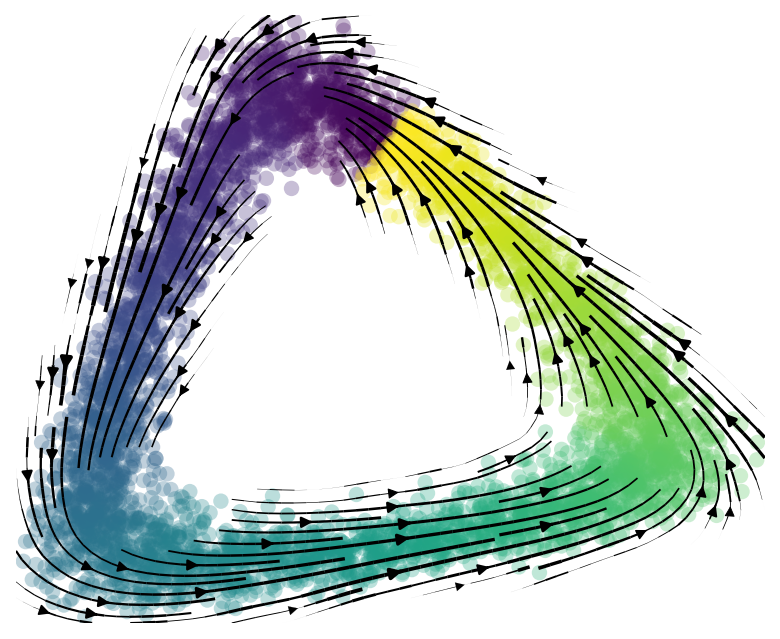

In [20]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='theta', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),
    # save='1.png'
)

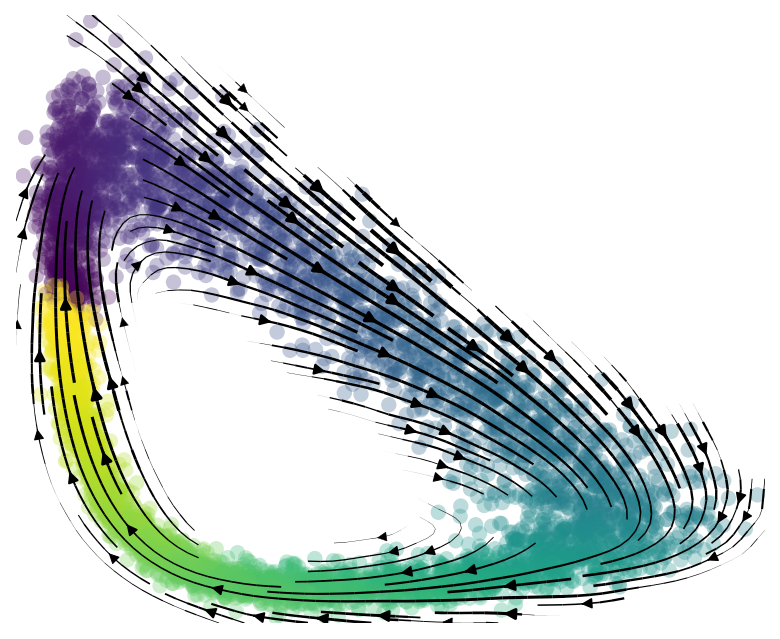

In [21]:
scv.pl.velocity_embedding_stream(
    latent_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='2dim', 
    color='theta', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),
    # save='2.png'
)

saving figure to file ../figures/streamplot_perturb.svg


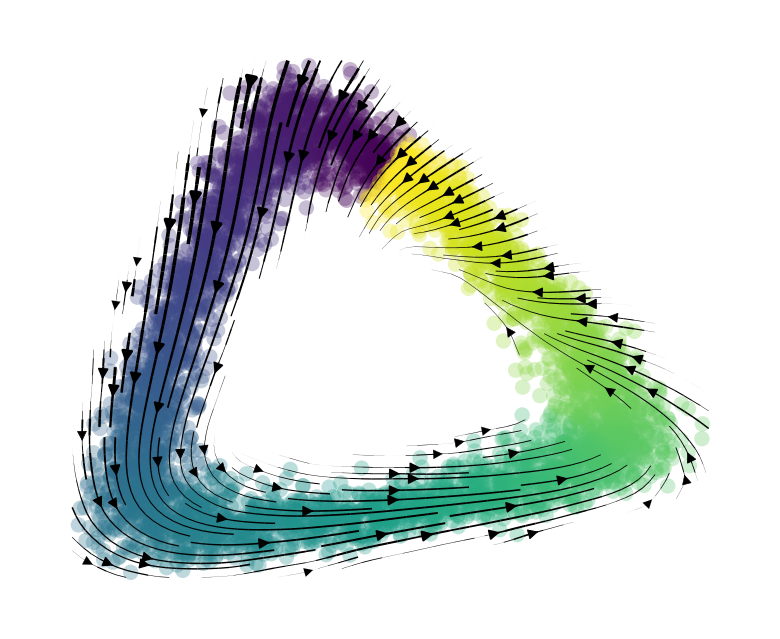

In [22]:
scv.pl.velocity_embedding_stream(
    perturb_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='pca', 
    color='theta', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),add_margin=0.1,rasterized=True,
    save='../figures/streamplot_perturb.svg'
)

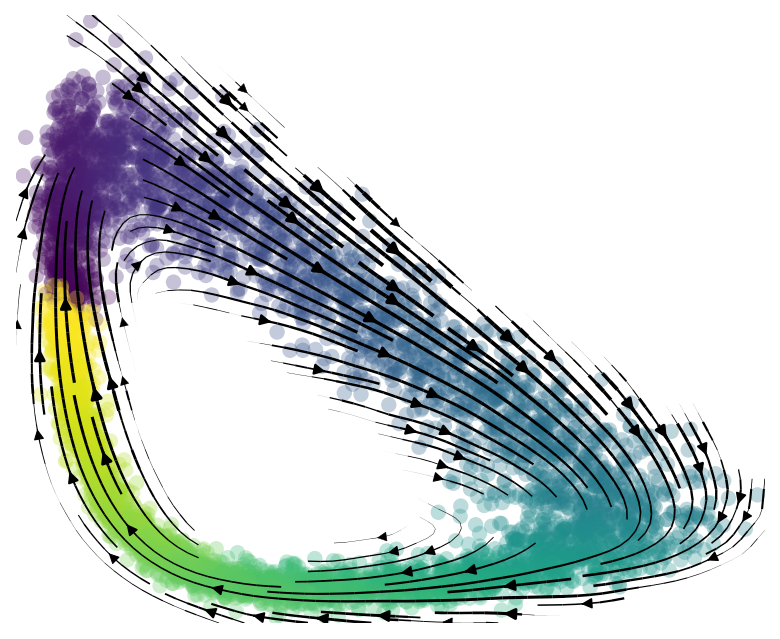

In [23]:
scv.pl.velocity_embedding_stream(
    perturb_adata, 
    density=2, smooth=0.5, min_mass=1,
    basis='2dim', 
    color='theta', 
    title="",
    fontsize=14,
    color_map='viridis',
    colorbar=False,
    figsize=(6,5),
    # save='2.png'
)

In [24]:
## 计算LAP
n_points = 30
EM_steps = 5
results = []

for i in range(len(basin_point)):
    for j in range(len(basin_point)):
        if i!=j:
            start = basin_point[i,:]
            end = basin_point[j,:]
            path, dt, action_opt = least_action_path(start, end, vf_func, jac_func, n_points=n_points, EM_steps=EM_steps, D=0.05)
            results.append({'start': i, 'end': j, 'path': path, 'dt': dt, 'action': action_opt})

In [25]:
basin_point_pca = (basin_point - np.mean(np_data, axis=0)) @ V

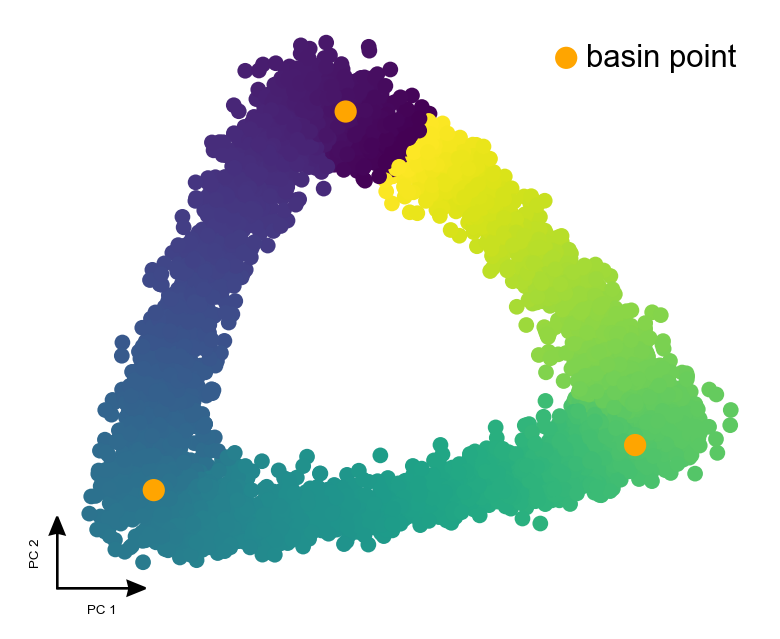

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
ax.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=100, edgecolors='none', label='basin point')
arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/basin_point_PC.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

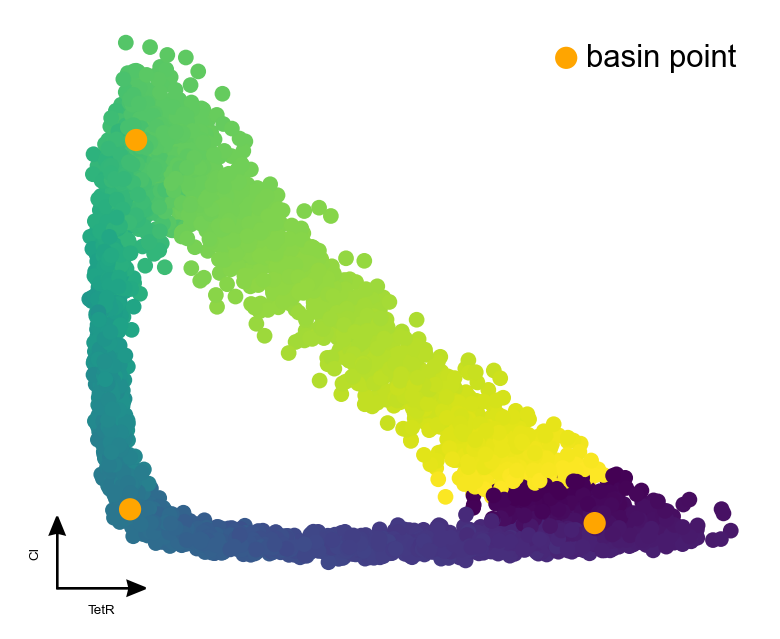

In [27]:
index1=4
index2=5
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data[:, index1], np_data[:, index2], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
ax.scatter(basin_point[:,index1],basin_point[:,index2], c='orange', s=100, edgecolors='none', label='basin point')

arrowed_spines(ax, columns=['TetR','CI'])
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/basin_point_2dim.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

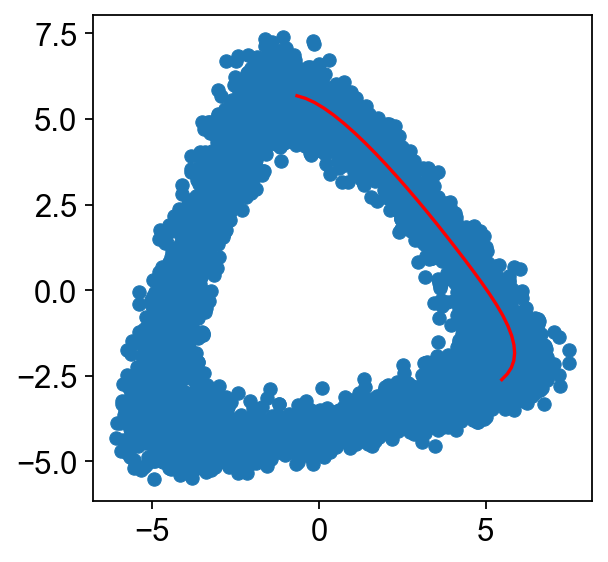

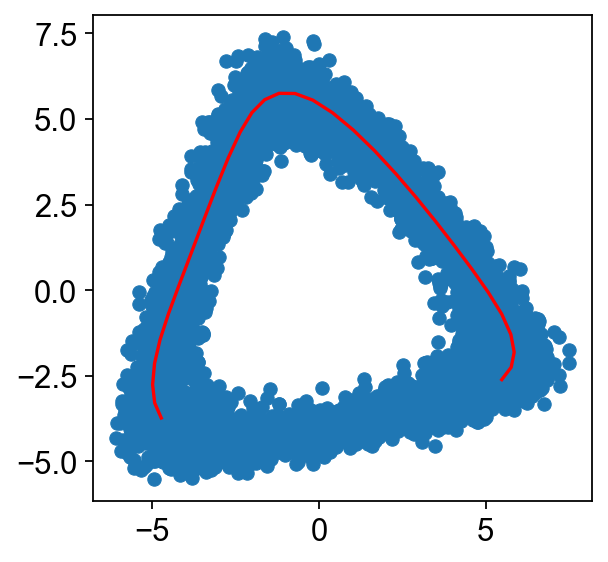

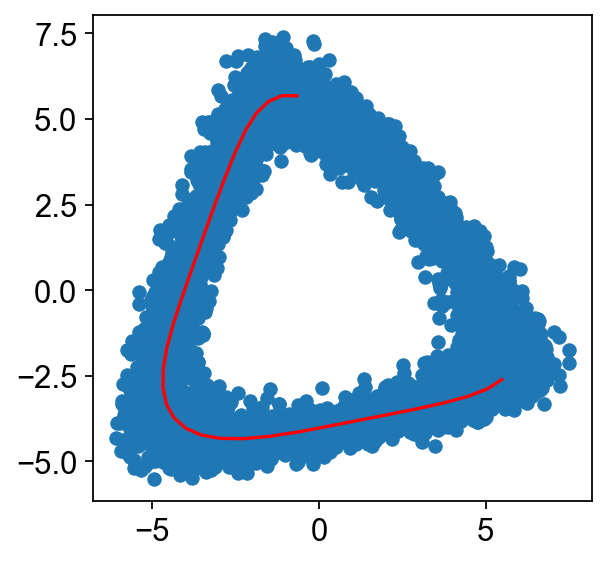

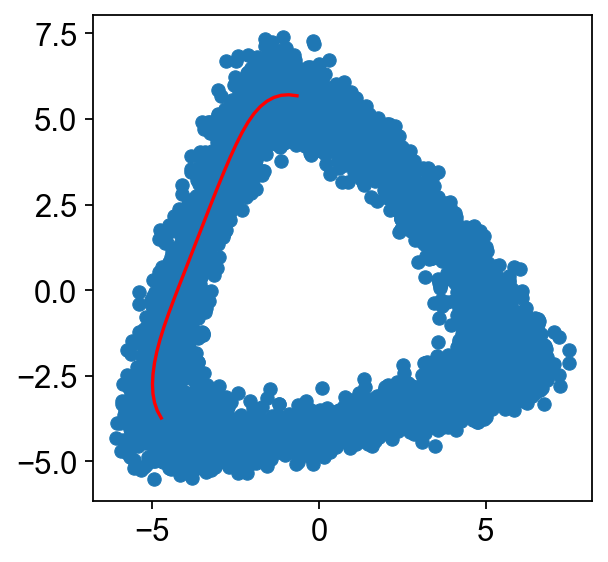

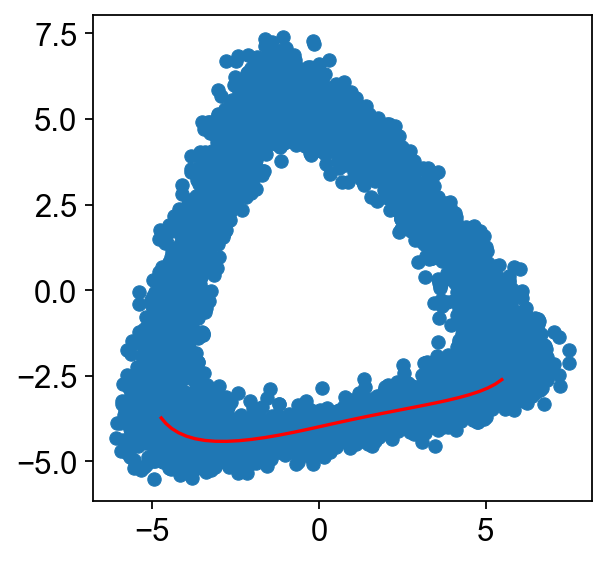

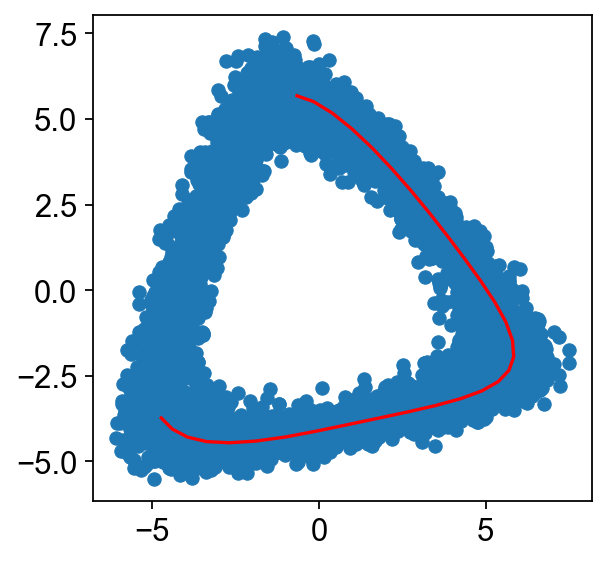

In [28]:
# plt.scatter(latent_z_pca[:,0],latent_z_pca[:,1])
for i in range(len(results)):
    plt.figure()
    plt.scatter(np_data_pca[:,0],np_data_pca[:,1])
    path = results[i]['path']
    path_pca = (path - np.mean(np_data, axis=0)) @ V
    plt.plot(path_pca[:,0],path_pca[:,1], color='red')

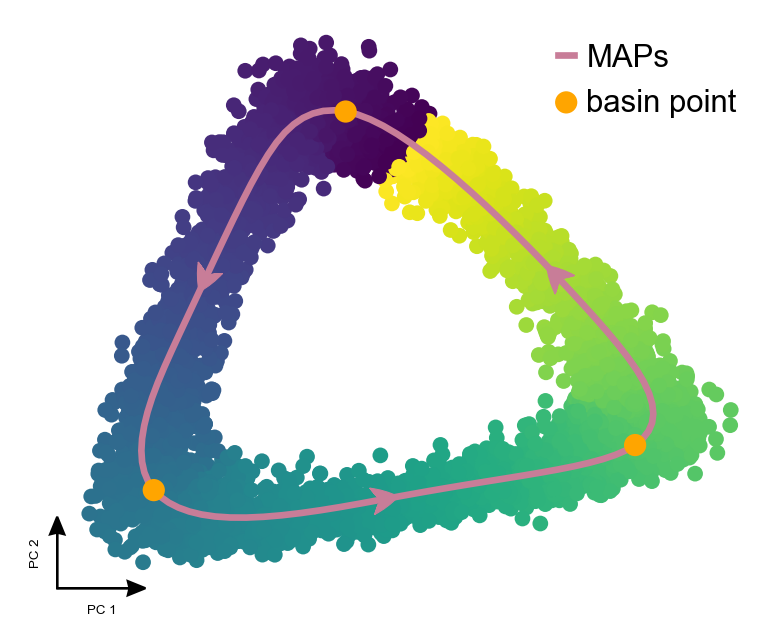

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
path = results[0]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[3]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[4]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

ax.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=100, edgecolors='none', zorder=2, label='basin point')
arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/MAP_PC.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

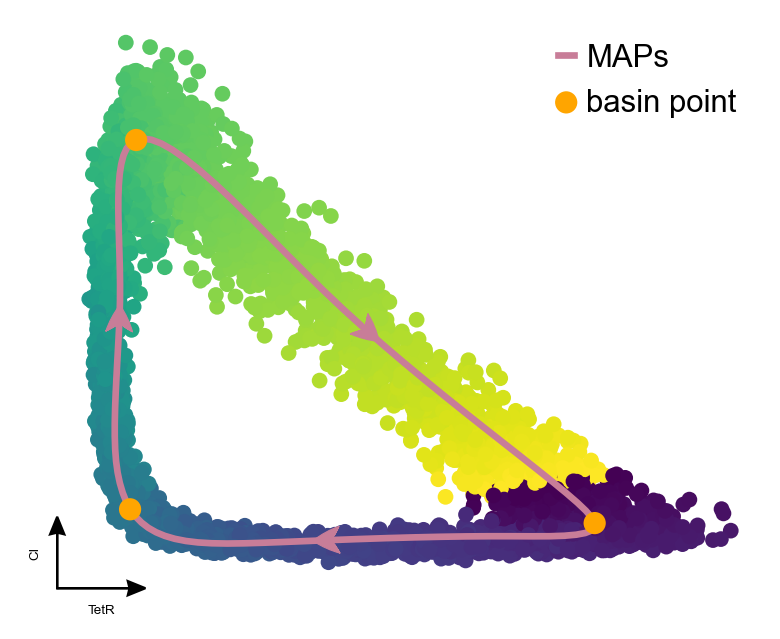

In [30]:
index1 = 4
index2 = 5
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data[:,index1],np_data[:,index2], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
path = results[0]['path']
ax.plot(path[:,index1],path[:,index2], color='#c87d98', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path[15, index1], path[15, index2]), 
                        (path[16, index1], path[16, index2]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[3]['path']
ax.plot(path[:,index1],path[:,index2], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path[15, index1], path[15, index2]), 
                        (path[16, index1], path[16, index2]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[4]['path']
ax.plot(path[:,index1],path[:,index2], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path[15, index1], path[15, index2]), 
                        (path[16, index1], path[16, index2]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

plt.scatter(basin_point[:,index1],basin_point[:,index2], c='orange', s=100, edgecolors='none', zorder=2, label='basin point')
arrowed_spines(ax, columns=['TetR','CI'])
ax.legend(loc='best', fontsize=14, frameon=False)

plt.savefig('../figures/MAP_2dim.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

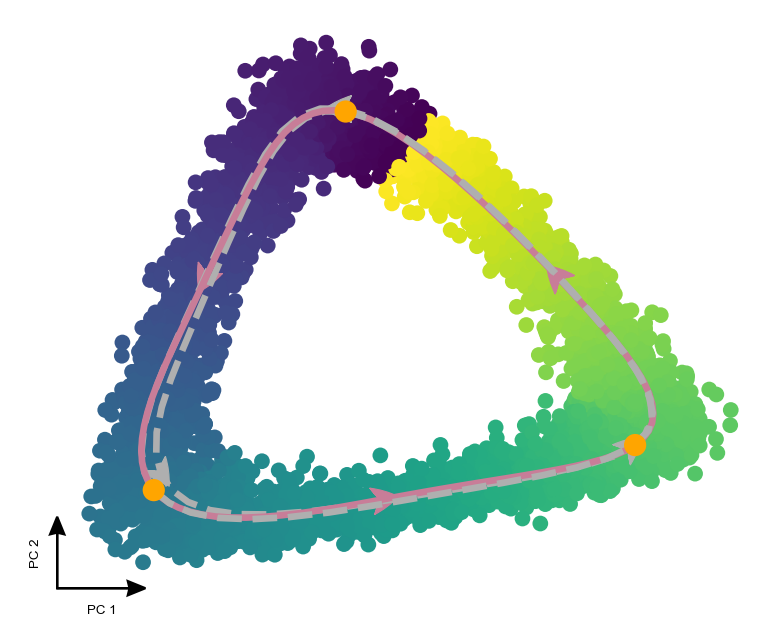

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)
path = results[0]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[1]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

path = results[2]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

path = results[3]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[4]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[5]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3)

arrow = FancyArrowPatch((path_pca[14, 0], path_pca[14, 1]), 
                        (path_pca[15, 0], path_pca[15, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

ax.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=100, edgecolors='none', zorder=2, label='basin point')
arrowed_spines(ax, columns='PC')
# ax.legend(loc='best', fontsize=12, frameon=False)

# plt.savefig('../figures/MAP_perturb.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

## 与极限环比较

In [32]:
# set initial points
x0 = np_data[0,:].reshape(-1,6)

# the length of sequence we predict
NK = 5000

t = torch.arange(0, 0.05 * NK, 0.05)

xx = np.zeros((6, NK))

x1 = torch.as_tensor(x0, dtype=torch.float32)
encoded, _ = encoder(x1)

latent_t = odeint(dynamics_learner, encoded, t, method='rk4')
latent_t = latent_t.permute(1, 2, 0).squeeze() # ode的解

for i in range(NK):
    encoded = latent_t[:, i]
    x0 = decoder(encoded)
    x0 = x0.detach().numpy()
    xx[:, i] = x0
    
latent_t = latent_t.detach().numpy()

xx_pca = ((xx.T - np.mean(np_data, axis=0)) @ V).T

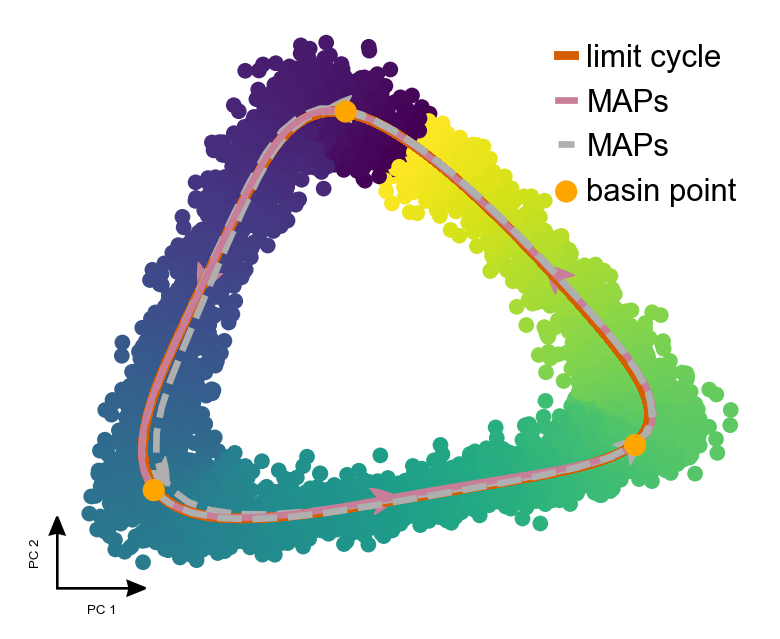

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=th, cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)

ax.plot(xx_pca[0, 2000:], xx_pca[1, 2000:], linewidth=4.0, color='#D55E00', label='limit cycle')
path = results[0]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[1]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3, label='MAPs')

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

path = results[2]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

path = results[3]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[4]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#c87d98', linewidth=3)

arrow = FancyArrowPatch((path_pca[15, 0], path_pca[15, 1]), 
                        (path_pca[16, 0], path_pca[16, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#c87d98')
ax.add_patch(arrow)

path = results[5]['path']
path_pca = (path - np.mean(np_data, axis=0)) @ V
ax.plot(path_pca[:,0],path_pca[:,1], color='#afafaf', linestyle='--', linewidth=3)

arrow = FancyArrowPatch((path_pca[14, 0], path_pca[14, 1]), 
                        (path_pca[15, 0], path_pca[15, 1]),
                        arrowstyle='fancy', mutation_scale=30, color='#afafaf')
ax.add_patch(arrow)

ax.scatter(basin_point_pca[:,0],basin_point_pca[:,1], c='orange', s=100, edgecolors='none', zorder=2, label='basin point')
arrowed_spines(ax, columns='PC')
ax.legend(loc='best', fontsize=14, frameon=False)

# plt.savefig('../figures/MAP_LC_compare.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [34]:
results

[{'start': 0,
  'end': 1,
  'path': array([[2.64113569, 0.61350054, 5.16046429, 0.68249154, 0.73431218,
          7.07890081],
         [2.48601464, 0.62917545, 5.32861827, 0.60047754, 0.82688242,
          7.10152401],
         [2.33695   , 0.65236083, 5.47694914, 0.53424936, 0.93648335,
          7.08281689],
         [2.19466887, 0.68321335, 5.60260988, 0.48206176, 1.06415042,
          7.02158945],
         [2.05941087, 0.72260293, 5.70352702, 0.44203002, 1.21087973,
          6.91756158],
         [1.93105518, 0.77110435, 5.77843459, 0.41189222, 1.37692796,
          6.7716656 ],
         [1.80974067, 0.82970709, 5.82577659, 0.38968993, 1.56248359,
          6.58576179],
         [1.69585661, 0.89805103, 5.84546717, 0.374276  , 1.76594675,
          6.36209949],
         [1.59000874, 0.97605165, 5.83801684, 0.36519656, 1.98487654,
          6.1052284 ],
         [1.49218858, 1.06363707, 5.80496223, 0.36173443, 2.21662977,
          5.82016865],
         [1.40066268, 1.16182132, 5.